<a href="https://colab.research.google.com/github/ozodbekAI/Data-Scince-and-AI-Portfolio/blob/main/Medical_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahulvyasm/medical-insurance-cost-prediction")

print("Path to dataset files:", path)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import joblib


In [37]:
import warnings
warnings.filterwarnings("ignore")

In [38]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)

In [39]:
df = pd.read_csv(path + "/medical_insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [40]:
df.shape

(2772, 7)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [42]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [43]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [44]:
df.duplicated().sum()

np.int64(1435)

In [45]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [46]:
dup_counts = df.groupby(list(df.columns)).size().reset_index(name="count")
dup_counts["count"].value_counts()

,count
count,
2,1288
4,49


In [47]:
df.drop_duplicates(inplace=True)

In [48]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [49]:
for col in ["sex","smoker", "region"]:
  print(f"----{col}----")
  print(df[col].value_counts())
  print(df[col].value_counts(normalize=True).round(3))

----sex----
sex
male      675
female    662
Name: count, dtype: int64
sex
male      0.505
female    0.495
Name: proportion, dtype: float64
----smoker----
smoker
no     1063
yes     274
Name: count, dtype: int64
smoker
no     0.795
yes    0.205
Name: proportion, dtype: float64
----region----
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
region
southeast    0.272
southwest    0.243
northwest    0.242
northeast    0.242
Name: proportion, dtype: float64


In [50]:
for col in ["age", "bmi", "children", "charges"]:
  print(f"----{col}: skew = {df[col].skew():.3f}- kurtosis = {df[col].kurt():.3f}---")


----age: skew = 0.055- kurtosis = -1.244---
----bmi: skew = 0.284- kurtosis = -0.053---
----children: skew = 0.937- kurtosis = 0.201---
----charges: skew = 1.515- kurtosis = 1.604---


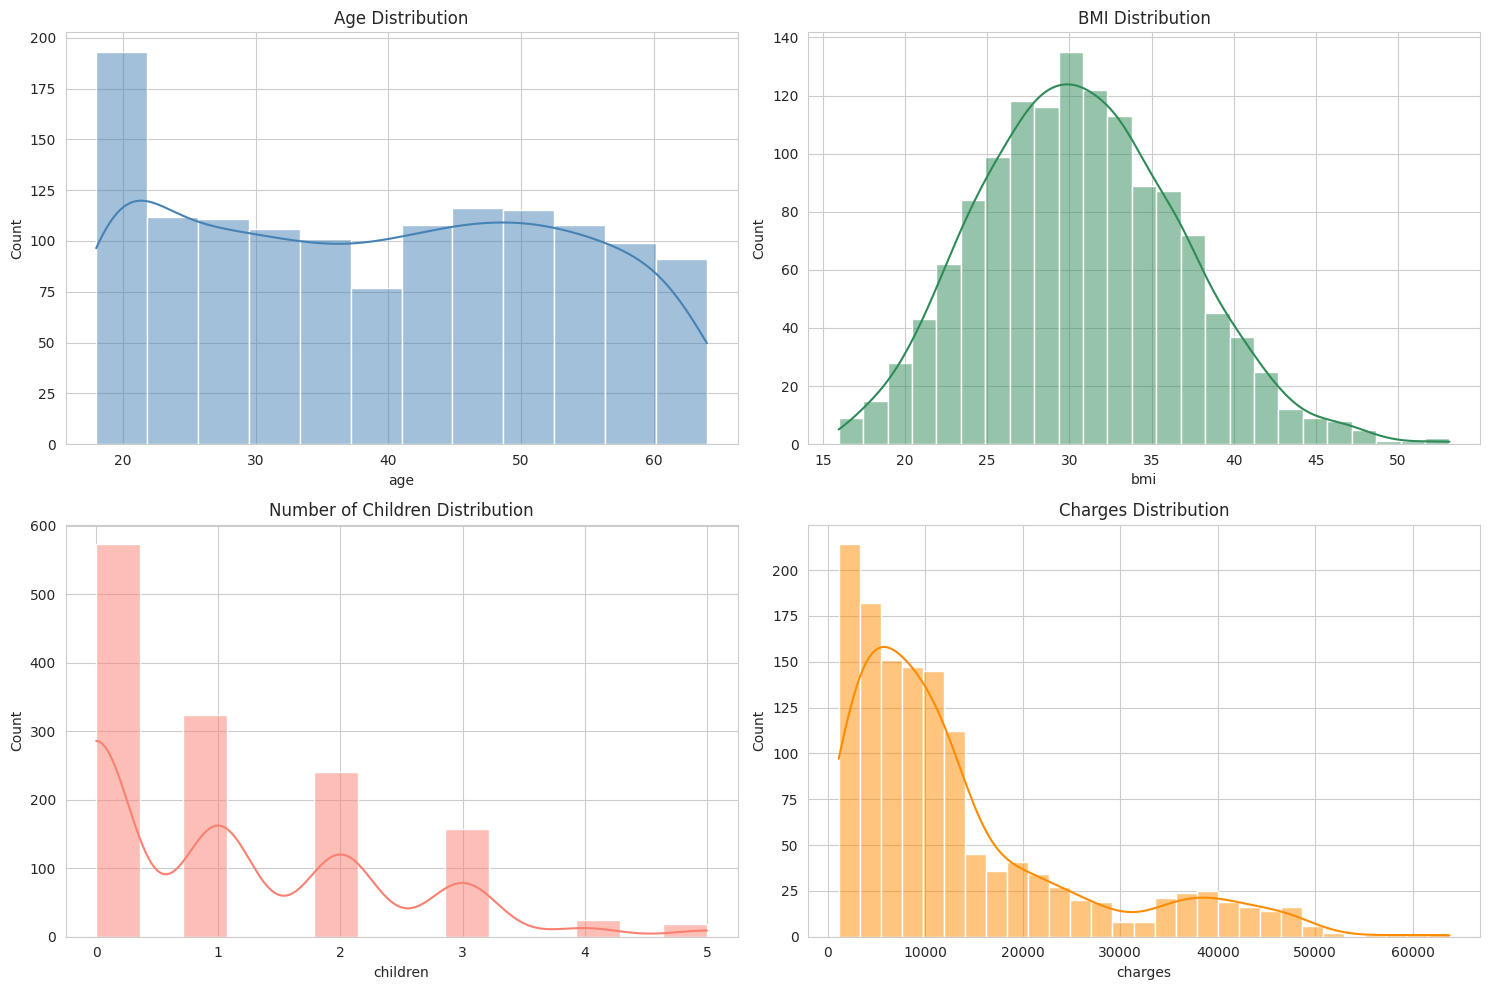

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df["age"], kde = True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Age Distribution")

sns.histplot(df["bmi"], kde = True, ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("BMI Distribution")

sns.histplot(df["children"], kde = True, ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("Number of Children Distribution")

sns.histplot(df["charges"], kde = True, ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Charges Distribution")

plt.tight_layout()

plt.show()

In [52]:
for col in ["bmi", "charges"]:
  Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

  n_out = ((df[col] < lower) | (df[col] > upper)).sum()

  print(f"{col}: bounds = ({lower:.1f}, {upper:.1f}, outliers = {n_out} ({n_out/len(df) * 100:.1f}%))")

bmi: bounds = (13.7, 47.3, outliers = 9 (0.7%))
charges: bounds = (-13120.7, 34524.8, outliers = 139 (10.4%))


In [53]:
df.groupby("smoker")["charges"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
smoker,,,,
no,8440.660307,7345.72660,5992.973800,1063
yes,32050.231832,34456.34845,11541.547176,274


In [54]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [55]:
def bmi_category(bmi):
  if bmi < 18.5:
    return "underweight"
  elif bmi < 25:
    return "normal"
  elif bmi < 30:
    return "overweight"
  else:
    return "obese"



In [56]:
df["bmi_category"] = df["bmi"].apply(bmi_category)

In [57]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,overweight
1,18,male,33.770,1,no,southeast,1725.55230,obese
2,28,male,33.000,3,no,southeast,4449.46200,obese
3,33,male,22.705,0,no,northwest,21984.47061,normal
4,32,male,28.880,0,no,northwest,3866.85520,overweight


In [58]:
df["bmi_category"].value_counts()

,count
bmi_category,
obese,706
overweight,386
normal,225
underweight,20


In [59]:
df.groupby("bmi_category")["charges"].mean().sort_values().round(2)

,charges
bmi_category,
underweight,8852.20
normal,10409.34
overweight,10987.51
obese,15572.04


In [60]:
df["log_charges"] = np.log1p(df["charges"])

In [61]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,obese,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,obese,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,normal,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,overweight,8.260455


In [62]:
df["charges"].skew()

np.float64(1.5153909108403483)

In [63]:
df["log_charges"].skew()

np.float64(-0.08955835073325998)

In [64]:
df_model = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region", "bmi_category"],
    drop_first=True
)

print(df_model.columns.to_list())

['age', 'bmi', 'children', 'charges', 'log_charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_obese', 'bmi_category_overweight', 'bmi_category_underweight']


In [65]:
df_model.head()

,age,bmi,children,charges,log_charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_obese,bmi_category_overweight,bmi_category_underweight
0,19,27.900,0,16884.92400,9.734236,False,True,False,False,True,False,True,False
1,18,33.770,1,1725.55230,7.453882,True,False,False,True,False,True,False,False
2,28,33.000,3,4449.46200,8.400763,True,False,False,True,False,True,False,False
3,33,22.705,0,21984.47061,9.998137,True,False,True,False,False,False,False,False
4,32,28.880,0,3866.85520,8.260455,True,False,True,False,False,False,True,False


In [66]:
feature_cols = [c for c in df_model.columns if c != "charges" and c != "log_charges"]
target_cols = ["log_charges"]

X = df_model[feature_cols]
y = df_model[target_cols]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [68]:
y_test_rel = np.expm1(y_test)

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=6, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=6, learning_rate=0.05)
}

trained_models = {}
metrics_rows = []

for name, model in candidate_models.items():
  model.fit(X_train, y_train)
  y_pred_log = model.predict(X_test)
  y_pred = np.expm1(y_pred_log)

  rmse = np.sqrt(mean_squared_error(y_test_rel, y_pred))
  mae = mean_absolute_error(y_test_rel, y_pred)
  r2 = r2_score(y_test_rel, y_pred)

  trained_models[name] = model
  metrics_rows.append(
      {
          "Model": name,
          "RMSE": rmse,
          "MAE": mae,
          "R2": r2
      }
  )
  print(f"{name} -> RMSE = {rmse:.3f}, MAE = {mae:.3f}, R2 = {r2:.3f}")

Linear Regression -> RMSE = 9430.547, MAE = 4587.526, R2 = 0.331
Random Forest -> RMSE = 4701.034, MAE = 2155.241, R2 = 0.834
Gradient Boosting -> RMSE = 4981.664, MAE = 2544.745, R2 = 0.813


In [72]:
results = pd.DataFrame(metrics_rows).sort_values("R2", ascending=False).reset_index(drop=True)

In [73]:
results

,Model,RMSE,MAE,R2
0,Random Forest,4701.033634,2155.241256,0.833805
1,Gradient Boosting,4981.664190,2544.744998,0.813371
2,Linear Regression,9430.546539,4587.525938,0.331187


In [74]:
best_model_name = results.loc[0, "Model"]
best_model = trained_models[best_model_name]


In [75]:
best_model_name

'Random Forest'

In [76]:
best_model

RandomForestRegressor(max_depth=6, n_estimators=300, n_jobs=-1)

In [79]:
joblib.dump(best_model, "insurance_model.pkl")
joblib.dump(feature_cols, "model_features.pkl")
joblib.dump(best_model_name, "model_name.pkl")

['model_name.pkl']